In [1]:

from pathlib import Path
from datetime import datetime

from matplotlib import pyplot as plt
import numpy as np
import pydicom
from scipy import ndimage

from pylinac.core.image_generator import AS1200Image, AS1000Image
import pylinac.core.image_generator.layers as layers

from metrics import run_analysis_on_path

pylinac_version: 3.43.2
date_of_analysis: 2026-06-05T15:11:12.904060
warnings: []
x_metrics:
Left Penumbra (mm): 3.70969521309651
Right Penumbra (mm): 3.656648593138681
Symmetry (Area): 0.01743322370557856
Flatness (Difference) (%): 2.001115894839394
Point Difference Symmetry (%): -0.9845502706527842
Flatness Calculation by Variance (%): 2.001115894839394
Flatness (Ratio) (%): 104.08395649218217
Flatness Calculation by Ratio (IEC) (%): 104.08395649218217
Flatness Calculation by CAX Variance: 0.5255061759837002
Flatness Calculation by CAX Ratio: 1.039823422046776
Symmetry Calculation by CAX Point Difference (%): 0.9847616622097439
Symmetry Calculation by CAX Point Difference (%)-1: 0.9847616622097439
Symmetry Calculation by Point Ratio (IEC 976) (%): 0.9847616622097439
Field Width (mm): 379.6160279271431
y_metrics:
Left Penumbra (mm): 3.6158680388568345
Right Penumbra (mm): 3.694067854814279
Symmetry (Area): -0.014457107689100496
Flatness (Difference) (%): 1.5946989004587495
Point Diffe

In [2]:
def generate_dicom(file_out_name, layers):
    as1200 = AS1200Image()
    for layer in layers:
        as1200.add_layer(layer)
    as1200.generate_dicom(file_out_name=file_out_name, gantry_angle=0)
    plt.imsave(file_out_name.with_suffix('.png'), as1200.image)
    return as1200.image

In [3]:
dir_path = Path(".")
dir_path = dir_path / "Flatness"
dir_path.mkdir(parents=True, exist_ok=True)

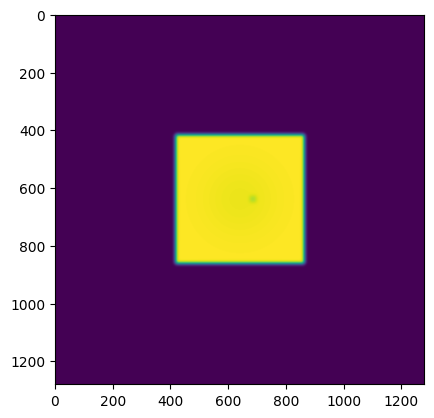

In [13]:
as1200 = AS1200Image()
as1200.add_layer(layers.FilteredFieldLayer(
    field_size_mm=(100, 100)
))
subtractimage = AS1200Image()
subtractimage.add_layer(layers.PerfectFieldLayer(
    field_size_mm=(5, 5),
    cax_offset_mm=(0, 10)
    #alpha=0.5
))
as1200.image = as1200.image - 0.1 * subtractimage.image

as1200.add_layer(layers.GaussianFilterLayer())

as1200.generate_dicom(file_out_name="artifact_test.dcm", gantry_angle=0)
plt.imshow(as1200.image)

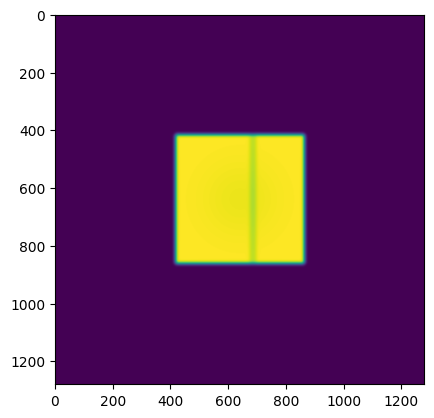

In [17]:
as1200 = AS1200Image()
as1200.add_layer(layers.FilteredFieldLayer(
    field_size_mm=(100, 100)
))
subtractimage = AS1200Image()
subtractimage.add_layer(layers.PerfectFieldLayer(
    field_size_mm=(100, 5),
    cax_offset_mm=(0, 10)
    #alpha=0.5
))
as1200.image = as1200.image - 0.1 * subtractimage.image

as1200.add_layer(layers.GaussianFilterLayer())

as1200.generate_dicom(file_out_name="artifact_test.dcm", gantry_angle=0)
plt.imshow(as1200.image)

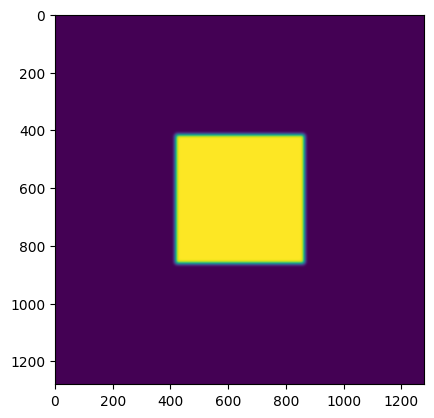

In [11]:
perfect_open_field_layers = [
    layers.PerfectFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    cax_offset_mm=(0, 0)), 
    layers.GaussianFilterLayer()
    ]

file_path = dir_path / "flatness_perfect_10x10.dcm"
as1200 = generate_dicom(file_path, perfect_open_field_layers)
plt.imshow(as1200)

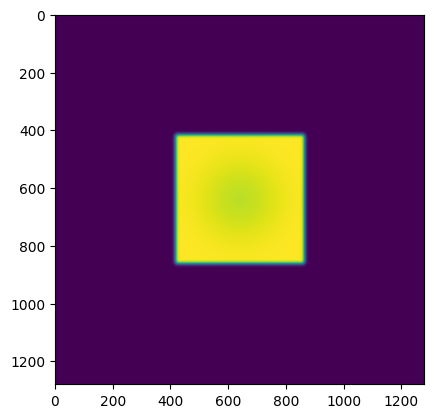

In [9]:
field_layers = [
    layers.FilteredFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    gaussian_height=0.1, 
    gaussian_sigma_mm=32.0,
    cax_offset_mm=(0, 0)), 
    layers.GaussianFilterLayer()
    ]

file_path = dir_path / "flatness_excess_horns_10x10.dcm"
as1200 = generate_dicom(file_path, field_layers)
plt.imshow(as1200)

pylinac_version: 3.43.2
date_of_analysis: 2026-06-01T15:10:20.687328
warnings: []
x_metrics:
Flatness Calculation by Variance (%): 0.9252603019270477
Flatness Calculation by Ratio (IEC) (%): 101.41060450020285
Flatness Calculation by CAX Variance: 0.47537683737477754
Flatness Calculation by CAX Ratio: 1.0200667852573104
Field Width (mm): 99.90491999454667
y_metrics:
Flatness Calculation by Variance (%): 0.9252603019270477
Flatness Calculation by Ratio (IEC) (%): 101.41060450020285
Flatness Calculation by CAX Variance: 0.47537683737477754
Flatness Calculation by CAX Ratio: 1.0200667852573104
Field Width (mm): 99.90491999454667
center:
mean: 64086.0
stdev: 0.0
min: 64086.0
max: 64086.0
normalization: Beam center
edge_type: Inflection Derivative
centering: Beam center



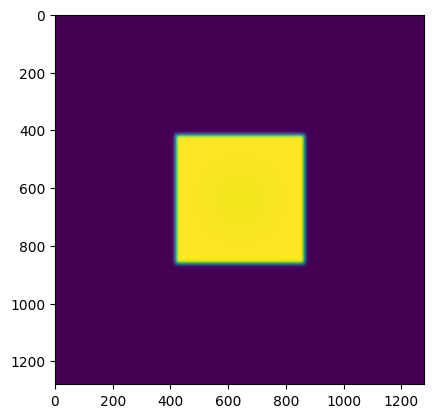

In [56]:
field_layers = [
    layers.FilteredFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    gaussian_height=0.0222, 
    gaussian_sigma_mm=32,
    cax_offset_mm=(0, 0)), 
    layers.GaussianFilterLayer()
    ]

file_path = dir_path / "flatness_filtered_10x10.dcm"
as1200 = generate_dicom(file_path, field_layers)
plt.imshow(as1200)
print(run_analysis_on_path(file_path))

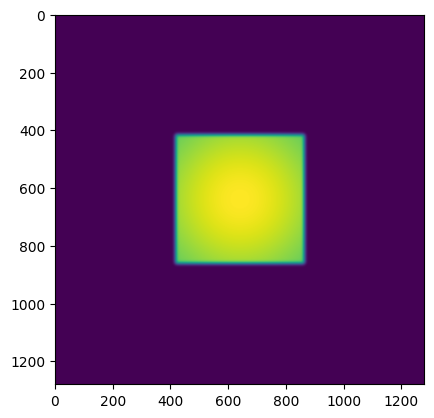

In [6]:
field_layers = [
    layers.FilterFreeFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    cax_offset_mm=(0, 0)), 
    layers.GaussianFilterLayer()
    ]

file_path = dir_path / "flatness_imperfect_fff_10x10.dcm"
as1200 = generate_dicom(file_path, field_layers)
plt.imshow(as1200)